# Fine Tuning BERT for Sentiment Analysis with PyTorch

References:
- [Fine Tuning BERT for Sentiment Analysis with PyTorch](https://wellsr.com/python/fine-tuning-bert-for-sentiment-analysis-with-pytorch/)
- [Twitter US Airline Sentiment](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?select=Tweets.csv)

- [RuntimeError: CUDA out of memory during loss.backward()](https://discuss.pytorch.org/t/runtimeerror-cuda-out-of-memory-during-loss-backward/53450/6)
- [Forms - Colaboratory](https://colab.research.google.com/notebooks/forms.ipynb)
- [Plotting loss curve](https://discuss.pytorch.org/t/plotting-loss-curve/42632/5)
- [Estratégias eficazes para lidar com conjuntos de dados desbalanceados](https://medium.com/@daniele.santiago/estrat%C3%A9gias-eficazes-para-lidar-com-conjuntos-de-dados-desbalanceados-5b873894483b)
- [Aprenda a balancear seus dados com Undersampling e Oversampling em Python](https://medium.com/@daniele.santiago/aprenda-a-balancear-seus-dados-com-undersampling-e-oversampling-em-python-6fd87095d717#:~:text=J%C3%A1%20o%20over%2Dsampling%2C%20por,t%C3%A9cnicas%20foi%20explicitada%20neste%20artigo.)
- [RandomOverSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html#imblearn.over_sampling.RandomOverSampler.fit_resample)
- [REPRODUCIBILITY](https://pytorch.org/docs/stable/notes/randomness.html)

In [3]:
# @title Environment running
running_local = False
if running_local:
    running_colab = running_kaggle = False
else:
    running_colab = True  # @param {type:"boolean"}
    running_kaggle = not running_colab  # @param {type:"boolean"}

In [4]:
if running_colab:
    from google.colab import drive

    drive.mount("/content/drive")

Mounted at /content/drive


## Installing and Importing Required Libraries

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import seaborn as sns
import time
import torch
import torch.nn as nn

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel

## Config

In [6]:
RANDOM_SEED = 103
TEST_SIZE = 0.2
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 5

TOKEN_MAX_LENGTH = 512
PRETRAINED_MODEL_PATH = "neuralmind/bert-base-portuguese-cased"
BERTIMBAU_HIDDEN_SIZE = 768

SAMPLE_REVIEWS = [
    "Empresa boa para trabalhar", # positive
    "Empresa ruim para trabalhar", # negative
    "Não tenho o que declarar", # neutral
]


if running_colab:
    GLASSDOOR_MODEL_PATH = "/content/drive/MyDrive/UFMT/Gestão e Ciência de Dados/Disciplinas/14 - Seminário e Metodologia da Pesquisa/Projetos/glassdoor-reviews-analysis-nlp/train_model/bertimbau-glassdoor-reviews-small-layer.bin"
    GLASSDOOR_FREEZING_MODEL_PATH = "/content/drive/MyDrive/UFMT/Gestão e Ciência de Dados/Disciplinas/14 - Seminário e Metodologia da Pesquisa/Projetos/glassdoor-reviews-analysis-nlp/train_model/bertimbau-glassdoor-reviews-freezing-small-layer.bin"
    PATH_TO_SAVE_MODEL = "/content/drive/MyDrive/UFMT/Gestão e Ciência de Dados/Disciplinas/14 - Seminário e Metodologia da Pesquisa/Projetos/glassdoor-reviews-analysis-nlp/train_model/"
if running_kaggle:
    GLASSDOOR_MODEL_PATH = "/kaggle/working/bertimbau-glassdoor-reviews-small-layer.bin"
    GLASSDOOR_FREEZING_MODEL_PATH = (
        "/kaggle/working/bertimbau-glassdoor-reviews-freezing-small-layer.bin"
    )
    PATH_TO_SAVE_MODEL = "/kaggle/working/"
if running_local:
    GLASSDOOR_MODEL_PATH = "./bertimbau-glassdoor-reviews-small-layer.bin"
    GLASSDOOR_FREEZING_MODEL_PATH = "./bertimbau-glassdoor-reviews-freezing-small-layer.bin"
    PATH_TO_SAVE_MODEL = "./train_model/"

In [7]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"There are {torch.cuda.device_count()} GPU(s) available.")
    print("Device name:", torch.cuda.get_device_name(0))
else:
    print("No GPU available, using the CPU instead.")
    device = torch.device("cpu")

There are 1 GPU(s) available.
Device name: Tesla T4


In [8]:
torch.manual_seed(RANDOM_SEED)

In [9]:
random.seed(RANDOM_SEED)

In [10]:
np.random.seed(RANDOM_SEED)

## Importing and Preprocessing the Dataset

In [11]:
if running_colab:
    dataset = pd.read_csv(
        "/content/drive/MyDrive/UFMT/Gestão e Ciência de Dados/Disciplinas/14 - Seminário e Metodologia da Pesquisa/Projetos/glassdoor-reviews-analysis-nlp/data_preparation/glassdoor_reviews_annotated.csv"
    )
else:
    if running_kaggle:
        dataset = pd.read_csv(
            "/kaggle/input/glassdoor-reviews-annotated/glassdoor_reviews_annotated.csv"
        )
    else:
        dataset = pd.read_csv("../data_preparation/glassdoor_reviews_annotated.csv")

In [12]:
dataset.head(2)

,review_id,company,employee_role,employee_detail,review_text,review_date,star_rating,sentiment,annotated
0,82630669,Tecnomapas,Recepcionista,"Ex-funcionário(a), mais de um ano","Companheirismo entre os colegas, oportunidade ...",2023-12-15,5.0,1,0
1,82630669,Tecnomapas,Recepcionista,"Ex-funcionário(a), mais de um ano",Não tive nenhum ponto negativo,2023-12-15,5.0,0,1


In [13]:
filtered_dataset = dataset.filter(["review_text", "sentiment"])

In [14]:
filtered_dataset.shape

(2532, 2)

In [15]:
filtered_dataset["sentiment"].value_counts()

,count
sentiment,
1,1269
-1,1021
0,242


In [16]:
num_labels = len(filtered_dataset["sentiment"].value_counts())

In [17]:
num_labels

3

In [18]:
filtered_dataset.head()

,review_text,sentiment
0,"Companheirismo entre os colegas, oportunidade ...",1
1,Não tive nenhum ponto negativo,0
2,Equipe bem prestativa e ótima de se trabalhar.,1
3,Modo home office ainda tem que ser melhorado.,-1
4,Única vantagem era o trabalho ser home office,0


Replace negative sentiment (-1) to 2, to avoid PyTorch errors.

In [19]:
filtered_dataset["sentiment"] = filtered_dataset["sentiment"].apply(
    lambda x: 2 if x == -1 else x
)

In [20]:
filtered_dataset.head()

,review_text,sentiment
0,"Companheirismo entre os colegas, oportunidade ...",1
1,Não tive nenhum ponto negativo,0
2,Equipe bem prestativa e ótima de se trabalhar.,1
3,Modo home office ainda tem que ser melhorado.,2
4,Única vantagem era o trabalho ser home office,0


Shuffle the data before splitting it into training and testing sets to remove any inherent ordering in the data that could bias the model's learning process.

In [21]:
filtered_dataset = filtered_dataset.sample(frac=1, random_state=RANDOM_SEED)

In [22]:
train_data, test_data = train_test_split(
    filtered_dataset, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

In [23]:
train_data.shape

(2025, 2)

In [24]:
test_data.shape

(507, 2)

## Loading Bertimbau model

In [25]:
bertimbau = BertModel.from_pretrained(PRETRAINED_MODEL_PATH)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [26]:
tokenizer = BertTokenizer.from_pretrained(PRETRAINED_MODEL_PATH)

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

## Create a PyTorch Dataset

In [27]:
class GlassdoorReviewsDataset(Dataset):
    def __init__(self, data, tokenizer, token_max_length):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = token_max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        text = self.data.iloc[index]["review_text"]
        labels = self.data.iloc[index][["sentiment"]].values.astype(int)

        encoding = self.tokenizer(
            text,
            return_tensors="pt",
            padding=True,
            truncation=False,
            # max_length=self.max_length,
        )
        input_ids = encoding["input_ids"][0]
        attention_mask = encoding["attention_mask"][0]

        # resize the tensors to the same size
        input_ids = nn.functional.pad(
            input_ids, (0, self.max_length - input_ids.shape[0]), value=0
        )
        attention_mask = nn.functional.pad(
            attention_mask, (0, self.max_length - attention_mask.shape[0]), value=0
        )

        return input_ids, attention_mask, torch.tensor(labels)

In [28]:
train_dataset = GlassdoorReviewsDataset(train_data, tokenizer, TOKEN_MAX_LENGTH)
test_dataset = GlassdoorReviewsDataset(test_data, tokenizer, TOKEN_MAX_LENGTH)

In [29]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Creating a PyTorch Model

In [30]:
classifier = nn.Sequential(
    nn.Linear(BERTIMBAU_HIDDEN_SIZE, 50),
    nn.ReLU(),
    nn.Linear(50, num_labels),
)

In [31]:
class GlassdoorReviewsClassifier(nn.Module):
    def __init__(self, num_labels):
        super(GlassdoorReviewsClassifier, self).__init__()

        self.bert = BertModel.from_pretrained(PRETRAINED_MODEL_PATH)
        self.classifier = classifier


    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = outputs["last_hidden_state"][:, 0, :]
        x = self.classifier(x)
        return x

In [32]:
class GlassdoorReviewsClassifierFreezing(nn.Module):
    def __init__(self, num_labels):
        super(GlassdoorReviewsClassifierFreezing, self).__init__()

        for param in bertimbau.parameters():
            param.requires_grad = False

        self.bert = BertModel.from_pretrained(PRETRAINED_MODEL_PATH)
        self.classifier = classifier

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = outputs["last_hidden_state"][:, 0, :]
        x = self.classifier(x)
        return x

## Model training functions

In [33]:
def train(model, data_loader, loss_fun, optimizer, n_total_steps):
    model.train()

    running_loss = 0.0
    for i, batch in enumerate(data_loader):
        input_ids, attention_mask, labels = batch

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        labels = labels.view(-1)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)

        loss = loss_fun(logits, labels)

        loss.backward()
        optimizer.step()

        loss_value = loss.item()
        running_loss += loss_value

        if (i + 1) % BATCH_SIZE == 0:
            print(
                f"Training Batch {i + 1}/{n_total_steps}, \t\t loss = {loss_value:.4f}"
            )

    return running_loss / len(data_loader)

In [34]:
def test(model, data_loader, loss_fun, n_total_steps):
    model.eval()

    running_loss = 0.0
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            input_ids, attention_mask, labels = batch

            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            labels = labels.view(-1)
            labels = labels.to(device)

            logits = model(input_ids, attention_mask)
            loss = loss_fun(logits, labels)

            loss_value = loss.item()
            running_loss += loss_value

            if (i + 1) % BATCH_SIZE == 0:
                print(
                    f"Evaluating Batch {i + 1}/{n_total_steps}, \t\t loss = {loss_value:.4f}"
                )

    return running_loss / len(data_loader)

In [35]:
def show_loss(train_loss_per_epoch, test_loss_per_epoch, title):
    epochs = range(1, len(train_loss_per_epoch) + 1)

    train_data = {"epoch": epochs, "loss": train_loss_per_epoch, "type": "Train"}
    test_data = {"epoch": epochs, "loss": test_loss_per_epoch, "type": "Test"}
    df_loss = pd.concat([pd.DataFrame(train_data), pd.DataFrame(test_data)])

    plt.figure(figsize=(8, 6))
    sns.lineplot(data=df_loss, x="epoch", y="loss", hue="type", marker="o")

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    # plt.grid(True)
    plt.legend(title="Loss Type")
    plt.show()

In [36]:
def start_training(model, train_loader, loss_fun, optimizer, epochs, n_total_steps):
    train_losses = []
    test_losses = []
    start_time = time.time()

    for t in range(epochs):
        print(f"{'-'*20} Epoch: {t + 1}/{epochs} {'-'*20}")

        train_loss = train(model, train_loader, loss_fun, optimizer, n_total_steps)
        train_losses.append(train_loss)

        print("")

        test_loss = test(model, test_loader, loss_fun, n_total_steps)
        test_losses.append(test_loss)

        print(f"\nTrain Loss: {train_loss}, \t\t Test Loss: {test_loss}")
        print("\n\n")

    elapsed_time = time.time() - start_time
    print(f"Elapsed time: {time.strftime('%H:%M:%S', time.gmtime(elapsed_time))}")

    return train_losses, test_losses

## Model Evaluation functions

In [37]:
def evaluate_model(model, test_loader, device):
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            input_ids, attention_mask, labels = batch

            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            labels = labels.view(-1)
            labels = labels.to(device)

            outputs = model(input_ids, attention_mask)
            _, predictions = torch.max(outputs, 1)

            all_labels.append(labels.cpu().numpy())
            all_preds.append(predictions.cpu().numpy())

    all_labels = np.concatenate(all_labels, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)

    return all_labels, all_preds

In [38]:
def show_confusion_matrix(all_labels, all_preds, normalize=None):
    cm = confusion_matrix(all_labels, all_preds, normalize=normalize)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="g")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

In [39]:
def predict_reviews(model, reviews) -> None:
    class_names = ["neutral", "positive", "negative"]
    for review in reviews:
        encoded_review = tokenizer.encode_plus(
            review,
            max_length=TOKEN_MAX_LENGTH,
            add_special_tokens=True,
            return_token_type_ids=False,
            # pad_to_max_length=True, # deprecated
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )

        input_ids = encoded_review["input_ids"].to(device)
        attention_mask = encoded_review["attention_mask"].to(device)

        output = model(input_ids, attention_mask)
        _, prediction = torch.max(output, dim=1)
        probs = nn.functional.softmax(output, dim=1)

        print(f"Review text: {review}")
        # print(probs)
        print(pd.DataFrame(probs.tolist()[0], class_names)[0])
        print("\n")

    return None

## Training the Model (without oversampling)

In [40]:
model = GlassdoorReviewsClassifier(num_labels).to(device)
model_freezing = GlassdoorReviewsClassifierFreezing(num_labels).to(device)

In [41]:
loss_fun = nn.CrossEntropyLoss()

In [42]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
optimizer_freezing = torch.optim.Adam(model_freezing.parameters(), lr=LEARNING_RATE)

In [43]:
n_total_steps = len(train_loader)
n_total_steps

127

### Training Model without freezing BERT Layers

In [44]:
train_losses, test_losses = start_training(
    model, train_loader, loss_fun, optimizer, EPOCHS, n_total_steps
)

-------------------- Epoch: 1/5 --------------------
Training Batch 16/127, 		 loss = 0.7872
Training Batch 32/127, 		 loss = 0.9471
Training Batch 48/127, 		 loss = 0.5916
Training Batch 64/127, 		 loss = 0.2477
Training Batch 80/127, 		 loss = 0.3323
Training Batch 96/127, 		 loss = 0.2649
Training Batch 112/127, 		 loss = 0.0960

Evaluating Batch 16/127, 		 loss = 0.3758
Evaluating Batch 32/127, 		 loss = 0.1495

Train Loss: 0.46582259707094176, 		 Test Loss: 0.2309273617574945



-------------------- Epoch: 2/5 --------------------
Training Batch 16/127, 		 loss = 0.2355
Training Batch 32/127, 		 loss = 0.0770
Training Batch 48/127, 		 loss = 0.0302
Training Batch 64/127, 		 loss = 0.0828
Training Batch 80/127, 		 loss = 0.5207
Training Batch 96/127, 		 loss = 0.1207
Training Batch 112/127, 		 loss = 0.3651

Evaluating Batch 16/127, 		 loss = 0.3764
Evaluating Batch 32/127, 		 loss = 0.0410

Train Loss: 0.16671170622814357, 		 Test Loss: 0.20564971838030033



-------------------- 

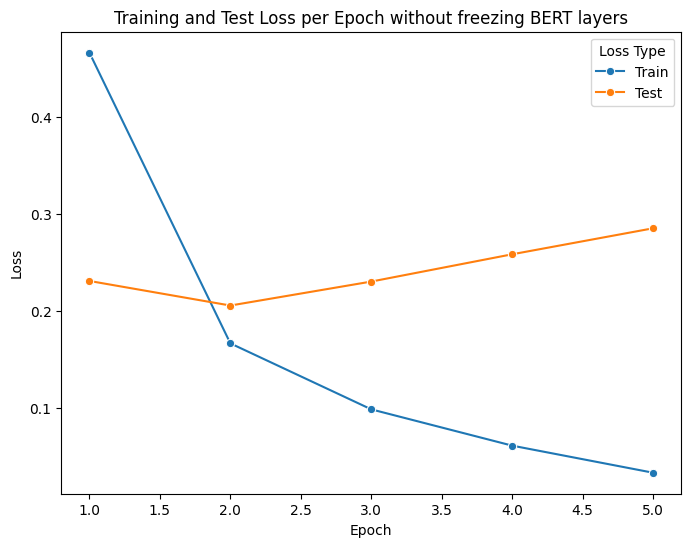

In [45]:
show_loss(train_losses, test_losses, title="Training and Test Loss per Epoch without freezing BERT layers")

#### Evaluating the Model

In [46]:
all_labels, all_preds = evaluate_model(model, test_loader, device)

In [47]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        51
           1       0.98      0.91      0.95       269
           2       0.89      0.98      0.93       187

    accuracy                           0.93       507
   macro avg       0.90      0.91      0.90       507
weighted avg       0.93      0.93      0.93       507



In [48]:
print(accuracy_score(all_labels, all_preds))

0.9289940828402367


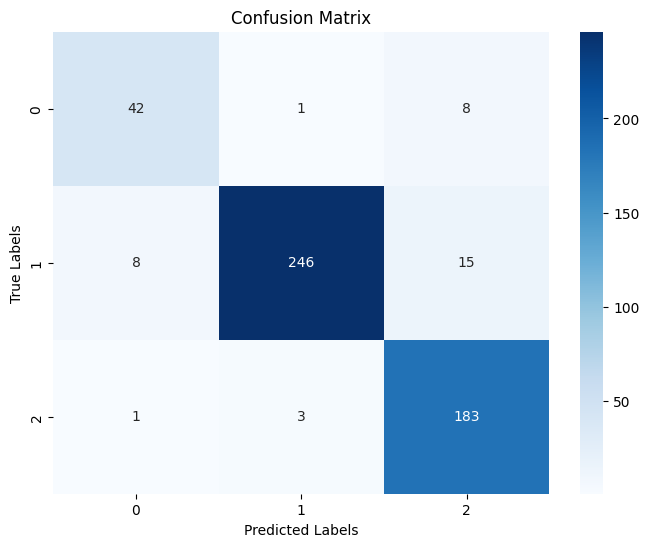

In [49]:
show_confusion_matrix(all_labels, all_preds)

In [50]:
# show_confusion_matrix(all_labels, all_preds, normalize="true")

#### Saving the model

In [51]:
torch.save(model.state_dict(), f"{PATH_TO_SAVE_MODEL}bertimbau-glassdoor-reviews-small-layer.bin")

#### Loading the model

In [52]:
loaded_model = GlassdoorReviewsClassifier(num_labels).to(device)
loaded_model.load_state_dict(torch.load(GLASSDOOR_MODEL_PATH, map_location=device))
loaded_model.eval()

GlassdoorReviewsClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

#### Sample prediction

In [53]:
predict_reviews(model, SAMPLE_REVIEWS)

Review text: Empresa boa para trabalhar
neutral     0.001046
positive    0.996413
negative    0.002541
Name: 0, dtype: float64


Review text: Empresa ruim para trabalhar
neutral     0.001011
positive    0.001470
negative    0.997519
Name: 0, dtype: float64


Review text: Não tenho o que declarar
neutral     0.971048
positive    0.021031
negative    0.007921
Name: 0, dtype: float64




### Training Model freezing BERT Layers

In [54]:
train_losses, test_losses = start_training(
    model_freezing, train_loader, loss_fun, optimizer_freezing, EPOCHS, n_total_steps
)

-------------------- Epoch: 1/5 --------------------
Training Batch 16/127, 		 loss = 0.8193
Training Batch 32/127, 		 loss = 0.3964
Training Batch 48/127, 		 loss = 0.2118
Training Batch 64/127, 		 loss = 0.1129
Training Batch 80/127, 		 loss = 0.2775
Training Batch 96/127, 		 loss = 0.4816
Training Batch 112/127, 		 loss = 0.1234

Evaluating Batch 16/127, 		 loss = 0.1249
Evaluating Batch 32/127, 		 loss = 0.5682

Train Loss: 0.37814196474908846, 		 Test Loss: 0.2718998492928222



-------------------- Epoch: 2/5 --------------------
Training Batch 16/127, 		 loss = 0.2095
Training Batch 32/127, 		 loss = 0.2165
Training Batch 48/127, 		 loss = 0.0364
Training Batch 64/127, 		 loss = 0.0633
Training Batch 80/127, 		 loss = 0.0558
Training Batch 96/127, 		 loss = 0.0308
Training Batch 112/127, 		 loss = 0.0428

Evaluating Batch 16/127, 		 loss = 0.1356
Evaluating Batch 32/127, 		 loss = 0.4593

Train Loss: 0.13456567137054806, 		 Test Loss: 0.19517210207413882



-------------------- 

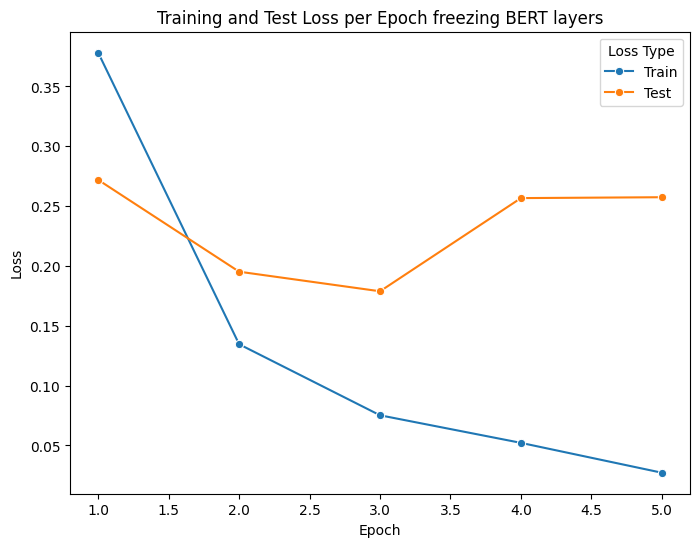

In [55]:
show_loss(train_losses, test_losses, title="Training and Test Loss per Epoch freezing BERT layers")

#### Evaluating the Model

In [56]:
all_labels, all_preds = evaluate_model(model_freezing, test_loader, device)

In [57]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.91      0.76      0.83        51
           1       0.93      0.97      0.95       269
           2       0.96      0.95      0.95       187

    accuracy                           0.94       507
   macro avg       0.93      0.89      0.91       507
weighted avg       0.94      0.94      0.94       507



In [58]:
print(accuracy_score(all_labels, all_preds))

0.9388560157790927


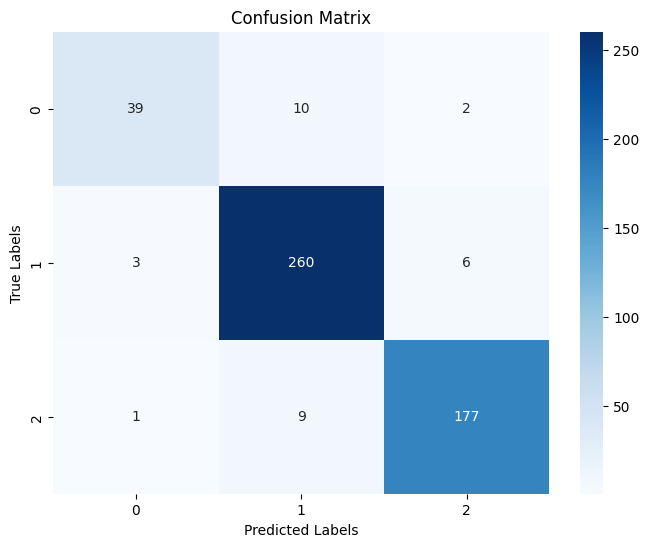

In [59]:
show_confusion_matrix(all_labels, all_preds)

In [60]:
# show_confusion_matrix(all_labels, all_preds, normalize="true")

#### Saving the model

In [61]:
torch.save(model.state_dict(), f"{PATH_TO_SAVE_MODEL}bertimbau-glassdoor-reviews-freezing-small-layer.bin")

#### Loading the model

In [62]:
loaded_model = GlassdoorReviewsClassifier(num_labels).to(device)
loaded_model.load_state_dict(torch.load(GLASSDOOR_FREEZING_MODEL_PATH, map_location=device))
loaded_model.eval()

GlassdoorReviewsClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

##### Sample prediction

In [63]:
predict_reviews(loaded_model, SAMPLE_REVIEWS)

Review text: Empresa boa para trabalhar
neutral     0.000337
positive    0.998744
negative    0.000918
Name: 0, dtype: float64


Review text: Empresa ruim para trabalhar
neutral     0.000399
positive    0.000556
negative    0.999045
Name: 0, dtype: float64


Review text: Não tenho o que declarar
neutral     0.987889
positive    0.008810
negative    0.003300
Name: 0, dtype: float64




## Training the model (with oversampling)

### Oversampling

In [64]:
def oversampling(train_df, minority_class=0, majority_classes=[1, 2]):
    # Desired number of samples for the minority class
    oversample_size = (
        train_df[train_df["sentiment"] == 0]["sentiment"].value_counts()[0] * 3
    )

    oversampler = RandomOverSampler(sampling_strategy={minority_class: oversample_size})
    X_res, y_res = oversampler.fit_resample(
        train_df[["review_text"]], train_df["sentiment"]
    )

    y_res_df = pd.DataFrame({"sentiment": y_res})
    resampled_df = pd.concat([X_res, y_res_df], axis=1)
    resampled_df.reset_index(drop=True, inplace=True)

    resampled_minority_df = resampled_df[resampled_df["sentiment"] == minority_class]

    # Concatenate the oversampled minority class with the majority class
    oversampled_df = pd.concat([train_df, resampled_minority_df])

    # Shuffle the DataFrame to randomize the order of samples
    oversampled_df = oversampled_df.sample(
        frac=1, random_state=RANDOM_SEED
    ).reset_index(drop=True)
    return oversampled_df

In [65]:
filtered_dataset.shape

(2532, 2)

In [66]:
filtered_dataset["sentiment"].value_counts()

,count
sentiment,
1,1269
2,1021
0,242


In [67]:
oversampled_filtered_dataset = oversampling(filtered_dataset)

In [68]:
oversampled_filtered_dataset.shape

(3258, 2)

In [69]:
oversampled_filtered_dataset["sentiment"].value_counts()

,count
sentiment,
1,1269
2,1021
0,968


### Training the Model

In [70]:
oversampled_train_data, oversampled_test_data = train_test_split(
    oversampled_filtered_dataset, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

In [71]:
oversampled_train_dataset = GlassdoorReviewsDataset(
    oversampled_train_data, tokenizer, TOKEN_MAX_LENGTH
)

oversampled_test_dataset = GlassdoorReviewsDataset(
    oversampled_test_data, tokenizer, TOKEN_MAX_LENGTH
)

In [72]:
oversampled_train_loader = DataLoader(
    oversampled_train_dataset, batch_size=BATCH_SIZE, shuffle=True
)
oversampled_test_loader = DataLoader(
    oversampled_test_dataset, batch_size=BATCH_SIZE, shuffle=False
)

In [73]:
oversampled_model = GlassdoorReviewsClassifier(num_labels).to(device)
oversampled_model_freezing = GlassdoorReviewsClassifierFreezing(num_labels).to(device)

In [74]:
loss_fun = nn.CrossEntropyLoss()

In [75]:
oversampled_optimizer = torch.optim.Adam(
    oversampled_model.parameters(), lr=LEARNING_RATE
)
oversampled_optimizer_freezing = torch.optim.Adam(
    oversampled_model_freezing.parameters(), lr=LEARNING_RATE
)

In [76]:
n_total_steps = len(oversampled_train_loader)
n_total_steps

163

#### Train without freezing

In [77]:
oversampled_train_losses, oversampled_test_losses = start_training(
    oversampled_model,
    oversampled_train_loader,
    loss_fun,
    oversampled_optimizer,
    EPOCHS,
    n_total_steps,
)

-------------------- Epoch: 1/5 --------------------
Training Batch 16/163, 		 loss = 0.6503
Training Batch 32/163, 		 loss = 0.4085
Training Batch 48/163, 		 loss = 0.9514
Training Batch 64/163, 		 loss = 0.1952
Training Batch 80/163, 		 loss = 0.0976
Training Batch 96/163, 		 loss = 0.8909
Training Batch 112/163, 		 loss = 0.2094
Training Batch 128/163, 		 loss = 0.0594
Training Batch 144/163, 		 loss = 0.5134
Training Batch 160/163, 		 loss = 0.4278

Evaluating Batch 16/163, 		 loss = 0.0262
Evaluating Batch 32/163, 		 loss = 0.0398

Train Loss: 0.32609023124070985, 		 Test Loss: 0.1491212801192887



-------------------- Epoch: 2/5 --------------------
Training Batch 16/163, 		 loss = 0.2347
Training Batch 32/163, 		 loss = 0.0606
Training Batch 48/163, 		 loss = 0.3124
Training Batch 64/163, 		 loss = 0.0276
Training Batch 80/163, 		 loss = 0.0235
Training Batch 96/163, 		 loss = 0.1580
Training Batch 112/163, 		 loss = 0.0230
Training Batch 128/163, 		 loss = 0.0156
Training Batc

##### Evaluating the Model

In [78]:
len(oversampled_train_losses)

5

In [79]:
len(oversampled_test_losses)

5

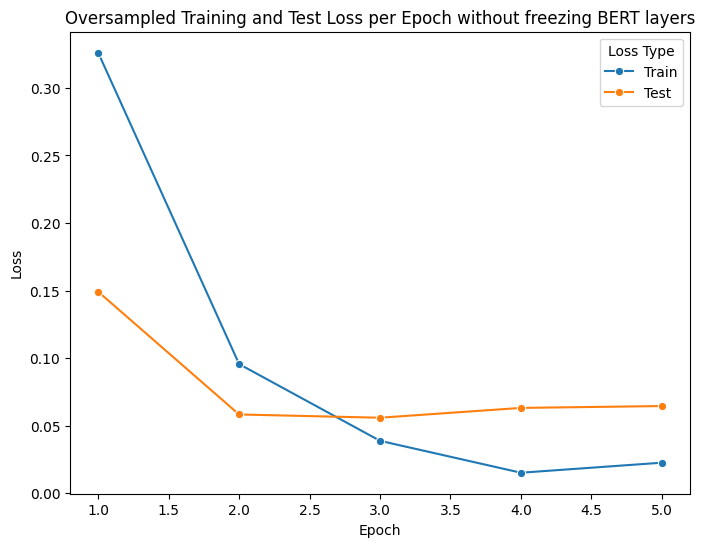

In [80]:
show_loss(oversampled_train_losses, oversampled_test_losses, title="Oversampled Training and Test Loss per Epoch without freezing BERT layers")

In [81]:
oversampled_all_labels, oversampled_all_preds = evaluate_model(
    oversampled_model, oversampled_test_loader, device
)

In [82]:
print(classification_report(oversampled_all_labels, oversampled_all_preds))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       197
           1       0.96      0.95      0.95       256
           2       0.95      0.96      0.95       199

    accuracy                           0.96       652
   macro avg       0.96      0.96      0.96       652
weighted avg       0.96      0.96      0.96       652



In [83]:
print(accuracy_score(oversampled_all_labels, oversampled_all_preds))

0.9601226993865031


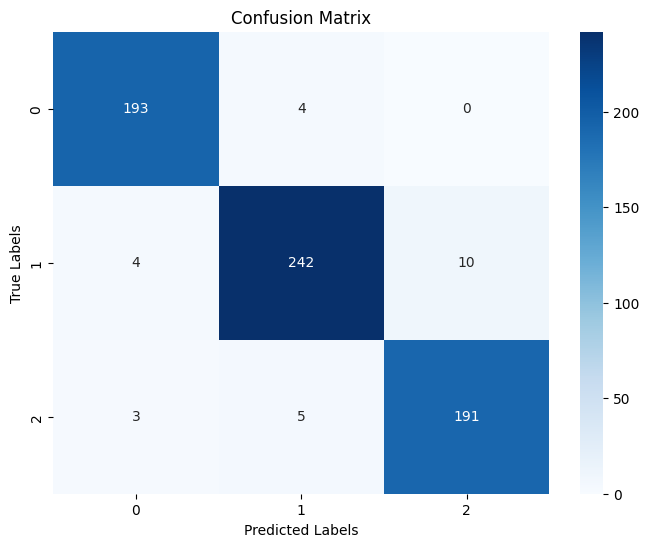

In [84]:
show_confusion_matrix(oversampled_all_labels, oversampled_all_preds)

##### Saving the model

In [85]:
torch.save(
    oversampled_model.state_dict(),
    f"{PATH_TO_SAVE_MODEL}bertimbau-glassdoor-reviews-oversampled-small-layer.bin",
)

##### Loading the model

In [86]:
oversampled_model = GlassdoorReviewsClassifier(num_labels).to(device)
oversampled_model.load_state_dict(
    torch.load(
        GLASSDOOR_MODEL_PATH.replace(
            f"bertimbau-glassdoor-reviews-small-layer.bin",
            f"bertimbau-glassdoor-reviews-oversampled-small-layer.bin",
        ),
        map_location=device,
    )
)
oversampled_model.eval()

GlassdoorReviewsClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

##### Sample prediction

In [87]:
predict_reviews(oversampled_model, SAMPLE_REVIEWS)

Review text: Empresa boa para trabalhar
neutral     0.000248
positive    0.998987
negative    0.000764
Name: 0, dtype: float64


Review text: Empresa ruim para trabalhar
neutral     0.000295
positive    0.001321
negative    0.998384
Name: 0, dtype: float64


Review text: Não tenho o que declarar
neutral     0.996648
positive    0.002489
negative    0.000863
Name: 0, dtype: float64




#### Train freezing

In [88]:
oversampled_train_losses, oversampled_test_losses = start_training(
    oversampled_model_freezing,
    oversampled_train_loader,
    loss_fun,
    oversampled_optimizer_freezing,
    EPOCHS,
    n_total_steps,
)

-------------------- Epoch: 1/5 --------------------
Training Batch 16/163, 		 loss = 0.4721
Training Batch 32/163, 		 loss = 0.2344
Training Batch 48/163, 		 loss = 0.3954
Training Batch 64/163, 		 loss = 0.2179
Training Batch 80/163, 		 loss = 0.1909
Training Batch 96/163, 		 loss = 0.1688
Training Batch 112/163, 		 loss = 0.1831
Training Batch 128/163, 		 loss = 0.1104
Training Batch 144/163, 		 loss = 0.4340
Training Batch 160/163, 		 loss = 0.0379

Evaluating Batch 16/163, 		 loss = 0.0523
Evaluating Batch 32/163, 		 loss = 0.0493

Train Loss: 0.3006188009002823, 		 Test Loss: 0.10140454157954082



-------------------- Epoch: 2/5 --------------------
Training Batch 16/163, 		 loss = 0.0400
Training Batch 32/163, 		 loss = 0.0263
Training Batch 48/163, 		 loss = 0.0381
Training Batch 64/163, 		 loss = 0.0323
Training Batch 80/163, 		 loss = 0.0143
Training Batch 96/163, 		 loss = 0.0186
Training Batch 112/163, 		 loss = 0.1216
Training Batch 128/163, 		 loss = 0.0199
Training Batc

##### Evaluating the Model

In [89]:
len(oversampled_train_losses)

5

In [90]:
len(oversampled_test_losses)

5

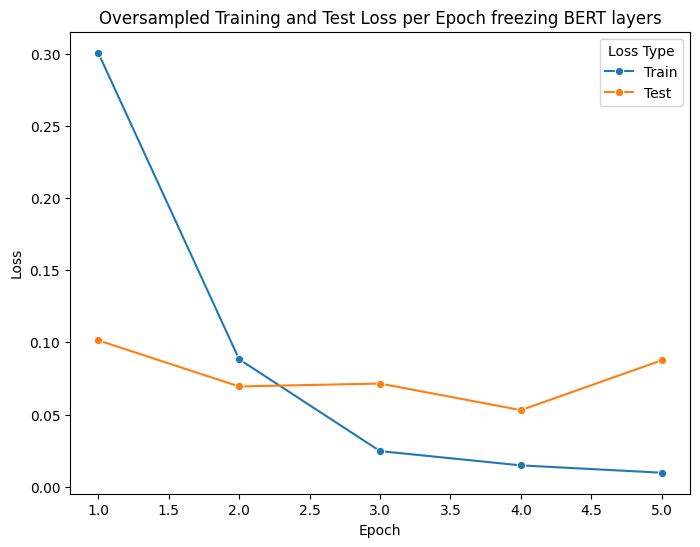

In [91]:
show_loss(
    oversampled_train_losses,
    oversampled_test_losses,
    title="Oversampled Training and Test Loss per Epoch freezing BERT layers",
)

In [92]:
oversampled_all_labels, oversampled_all_preds = evaluate_model(
    oversampled_model_freezing, oversampled_test_loader, device
)

In [93]:
print(classification_report(oversampled_all_labels, oversampled_all_preds))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       197
           1       0.92      0.98      0.95       256
           2       0.99      0.87      0.93       199

    accuracy                           0.95       652
   macro avg       0.96      0.95      0.95       652
weighted avg       0.95      0.95      0.95       652



In [94]:
print(accuracy_score(oversampled_all_labels, oversampled_all_preds))

0.9493865030674846


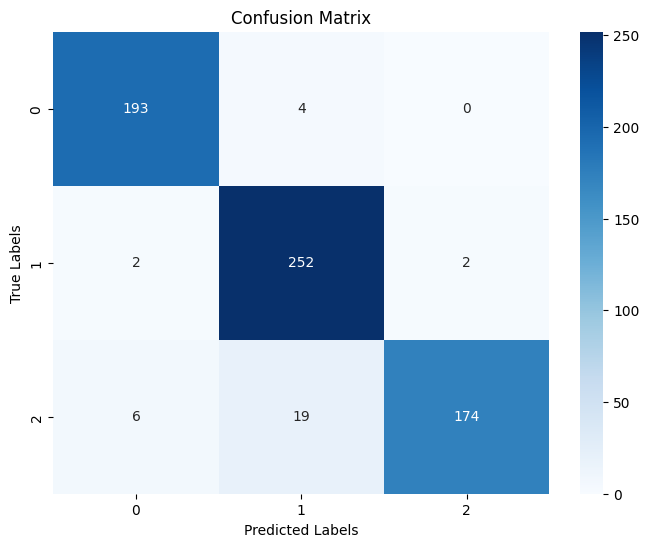

In [95]:
show_confusion_matrix(oversampled_all_labels, oversampled_all_preds)

##### Saving the model

In [96]:
torch.save(
    oversampled_model.state_dict(),
    f"{PATH_TO_SAVE_MODEL}bertimbau-glassdoor-reviews-oversampled-freezing-small-layer.bin",
)

##### Loading the model

In [97]:
oversampled_model = GlassdoorReviewsClassifier(num_labels).to(device)
oversampled_model.load_state_dict(
    torch.load(
        GLASSDOOR_MODEL_PATH.replace(
            f"bertimbau-glassdoor-reviews-small-layer.bin",
            f"bertimbau-glassdoor-reviews-oversampled-freezing-small-layer.bin",
        ),
        map_location=device,
    )
)
oversampled_model.eval()

GlassdoorReviewsClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

##### Sample prediction

In [98]:
predict_reviews(oversampled_model, SAMPLE_REVIEWS)

Review text: Empresa boa para trabalhar
neutral     0.000078
positive    0.999630
negative    0.000292
Name: 0, dtype: float64


Review text: Empresa ruim para trabalhar
neutral     0.000109
positive    0.000557
negative    0.999334
Name: 0, dtype: float64


Review text: Não tenho o que declarar
neutral     0.998783
positive    0.000905
negative    0.000312
Name: 0, dtype: float64


